# Sampling from the trained DDPM

The training notebook taught the U-Net to predict the noise that produced $x_t$ from $x_0$. This notebook uses that ability to reverse the diffusion process: starting from pure Gaussian noise $x_T$ and iteratively denoising one step at a time until we reach $x_0$ — a generated image.

### The reverse process

For each timestep, the model produces $\epsilon_\theta(x_t, t)$, its estimate of the noise component of $x_t$. The DDPM paper shows the optimal reverse-step distribution $p_\theta(x_{t-1} \mid x_t)$ is Gaussian with mean

$$
\mu_\theta(x_t, t) = \frac{1}{\sqrt{\alpha_t}} \left( x_t - \frac{\beta_t}{\sqrt{1 - \bar{\alpha}_t}}\, \epsilon_\theta(x_t, t) \right)
$$

and variance $\sigma_t^2 = \beta_t$ (the simpler of the two choices given in the paper).

One reverse step:

$$
x_{t-1} = \mu_\theta(x_t, t) + \sigma_t\, z, \qquad z \sim \mathcal{N}(0, I)
$$

with no noise added on the final $t=0$ step.

### What this notebook does

1. Reconstructs the noise schedule from notebook 01.
2. Imports the U-Net from `src/model.py` and loads weights trained in notebook 03.
3. Implements `p_sample` (one reverse step) and `sample` (the full loop).
4. Generates a grid of MNIST samples from pure noise.
5. Visualizes the denoising trajectory for a single sample.

In [1]:
import glob
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


## 1. Noise schedule

Same linear schedule as notebook 01. We need the same `betas`, `alphas`, `alphas_cumprod` here because every reverse step indexes into them.

In [2]:
T = 200
beta_start = 1e-4
beta_end = 0.02

betas = torch.linspace(beta_start, beta_end, T, device=device)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)

print(f"T = {T}, schedule on device: {betas.device}")

T = 200, schedule on device: cuda:0


## 2. Model and weights

Clone the repo, import the `UNet` class from `src/model.py`, and load the weights produced by the training notebook (added as input to this notebook).

In [3]:
# Clone repo and import UNet from src/model.py
!git clone -q https://github.com/baruahrithik/diffusion-from-scratch.git /tmp/diffusion-from-scratch

import sys
sys.path.insert(0, "/tmp/diffusion-from-scratch")
from src import UNet

# Construct the model with the same hyperparameters as training
model = UNet(
    in_channels=1,
    base_channels=32,
    channel_mults=(1, 2, 4),
    time_emb_dim=128,
).to(device)

# Find and load the trained weights
candidates = glob.glob("/kaggle/input/**/ddpm_mnist_weights.pt", recursive=True)
if not candidates:
    raise FileNotFoundError(
        "Couldn't find ddpm_mnist_weights.pt under /kaggle/input/. "
        "Did you add the 03-training notebook as input to this notebook?"
    )
weights_path = candidates[0]
print(f"Loading weights from: {weights_path}")

model.load_state_dict(torch.load(weights_path, map_location=device))
model.eval()
print(f"Loaded UNet ({sum(p.numel() for p in model.parameters()):,} parameters)")

Loading weights from: /kaggle/input/notebooks/baruahrithik/03-training/ddpm_mnist_weights.pt
Loaded UNet (1,112,801 parameters)


## 3. Single reverse step

`p_sample` implements one update $x_t \to x_{t-1}$. Given the model's noise prediction, it computes the mean, then optionally adds Gaussian noise (skipped at $t=0$).

In [4]:
@torch.no_grad()
def p_sample(model, x_t, t):
    """
    One reverse-process step: x_t -> x_{t-1}.

    x_t : (B, C, H, W) noisy image at timestep t
    t   : (B,) integer timesteps
    """
    # Predict noise
    eps_pred = model(x_t, t)

    # Coefficients, broadcast to image shape
    beta_t                         = betas[t].view(-1, 1, 1, 1)
    alpha_t                        = alphas[t].view(-1, 1, 1, 1)
    sqrt_one_minus_alpha_bar_t     = sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1)

    # Mean of p(x_{t-1} | x_t)
    mean = (1.0 / torch.sqrt(alpha_t)) * (
        x_t - (beta_t / sqrt_one_minus_alpha_bar_t) * eps_pred
    )

    # No noise on the final t=0 step
    if (t == 0).all():
        return mean

    sigma_t = torch.sqrt(beta_t)
    z = torch.randn_like(x_t)
    return mean + sigma_t * z

## 4. Full sampling and visualization

Start from $x_T \sim \mathcal{N}(0, I)$ and apply `p_sample` $T$ times. After 200 reverse steps we have $x_0$, our generated image.

Sampling 16 images at $T=200$ takes around 5–10 seconds on T4.

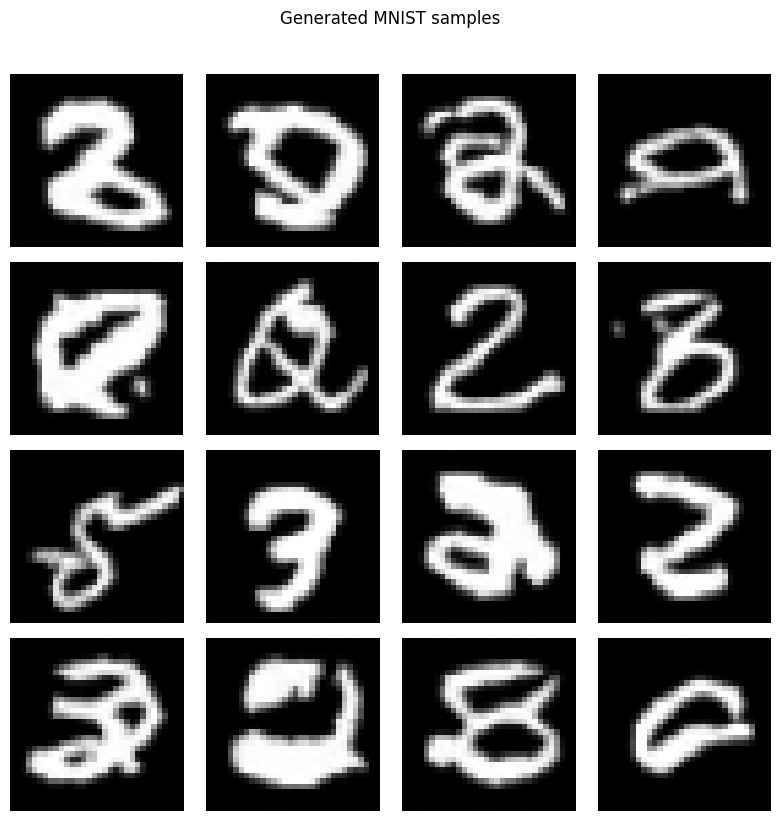

In [5]:
@torch.no_grad()
def sample(model, n_samples=16, image_size=32, channels=1):
    """Generate samples by reversing the diffusion process from pure noise."""
    model.eval()
    x = torch.randn(n_samples, channels, image_size, image_size, device=device)
    for t_val in reversed(range(T)):
        t = torch.full((n_samples,), t_val, device=device, dtype=torch.long)
        x = p_sample(model, x, t)
    return x


samples = sample(model, n_samples=16)
samples = ((samples + 1) / 2).clamp(0, 1).cpu()

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(samples[i, 0], cmap="gray")
    ax.axis("off")
plt.suptitle("Generated MNIST samples", y=1.02)
plt.tight_layout()
plt.savefig("generated_samples.png", dpi=100, bbox_inches="tight")
plt.show()

## 5. Denoising trajectory

A single sample's path from pure noise to digit. We record the state every 20 steps and visualize the sequence — you should see noise gradually resolving into a digit shape.

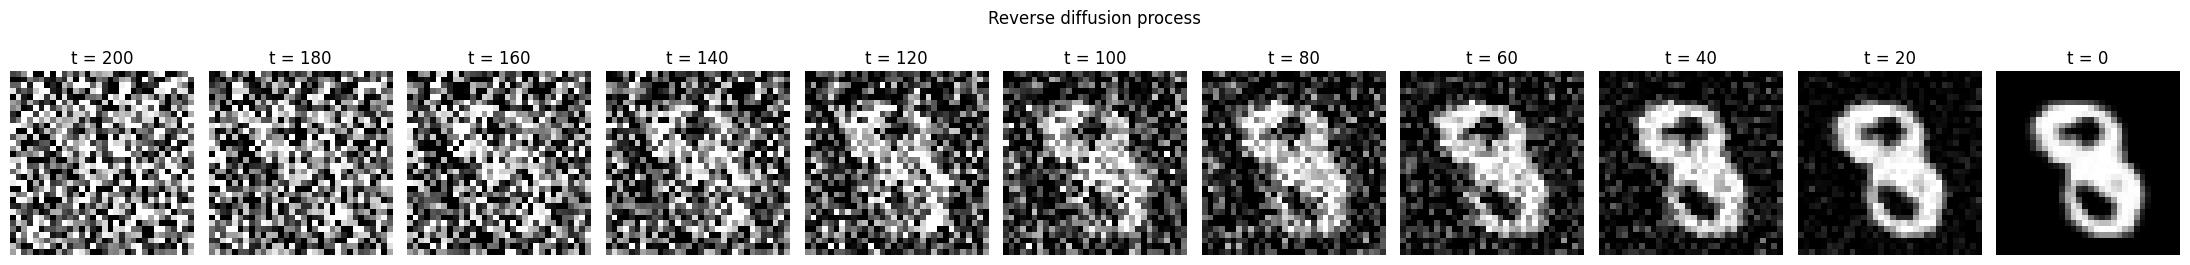

In [6]:
@torch.no_grad()
def sample_with_history(model, image_size=32, channels=1, save_every=20):
    """Sample one image and record intermediate states every `save_every` steps."""
    model.eval()
    x = torch.randn(1, channels, image_size, image_size, device=device)
    history = [(T, x.cpu().clone())]
    for t_val in reversed(range(T)):
        t = torch.full((1,), t_val, device=device, dtype=torch.long)
        x = p_sample(model, x, t)
        if t_val % save_every == 0 or t_val == 0:
            history.append((t_val, x.cpu().clone()))
    return history


history = sample_with_history(model)

fig, axes = plt.subplots(1, len(history), figsize=(2 * len(history), 2.5))
for ax, (t_val, x) in zip(axes, history):
    img = ((x[0, 0] + 1) / 2).clamp(0, 1)
    ax.imshow(img, cmap="gray")
    ax.set_title(f"t = {t_val}")
    ax.axis("off")
plt.suptitle("Reverse diffusion process", y=1.05)
plt.tight_layout()
plt.savefig("denoising_process.png", dpi=100, bbox_inches="tight")
plt.show()